In [1]:
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1                  2         2       

DATASET 1: Lung Cancer Dataset
First 5 rows
   GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       1   69        1               2        2              1   
1       1   74        2               1        1              1   
2       0   59        1               1        1              2   
3       1   63        2               2        2              1   
4       0   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER  
0    

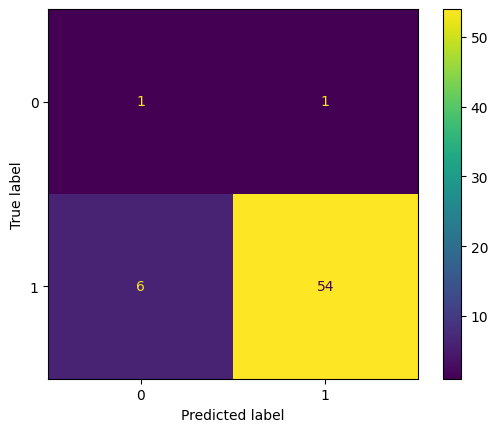


Logistic Regression Results : Dataset 1 (5-fold CV Baseline - All features)
Mean Accuracy : 0.8643
Mean Precision: 0.9670
Mean F1-score : 0.9181

Feature Importance Ranking (Absolute Coefficient Magnitude)
                  Feature  Importance
0   SWALLOWING DIFFICULTY    1.232686
1         CHRONIC DISEASE    1.227037
2                 FATIGUE    1.198142
3                COUGHING    1.155293
4                 ALLERGY    1.032629
5           PEER_PRESSURE    0.908162
6       ALCOHOL CONSUMING    0.840043
7          YELLOW_FINGERS    0.807060
8                 ANXIETY    0.759817
9                 SMOKING    0.684689
10               WHEEZING    0.518987
11                    AGE    0.285934
12             CHEST PAIN    0.260665
13                 GENDER    0.259269
14    SHORTNESS OF BREATH    0.171108


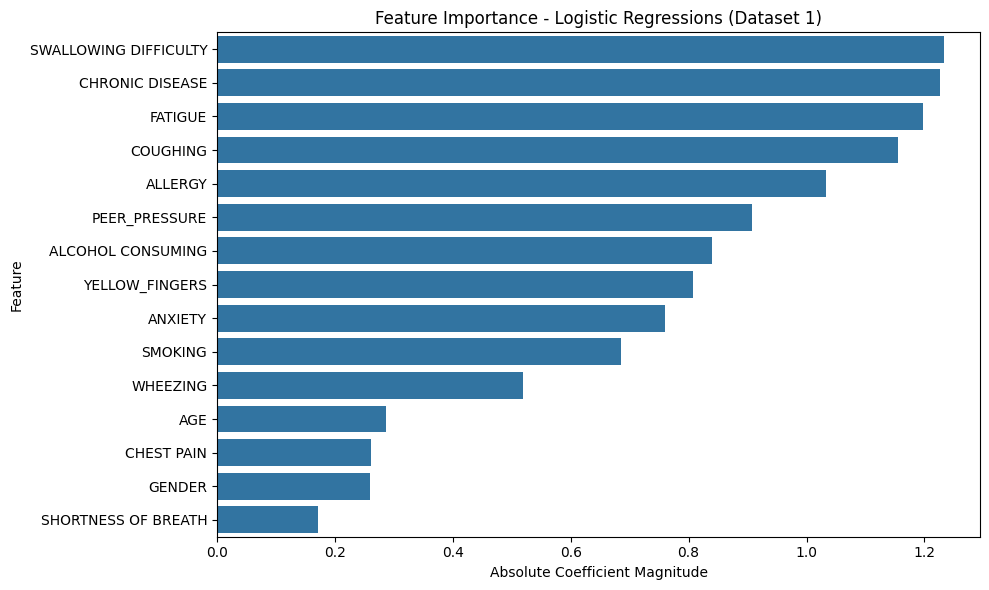


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Feature  Accuracy  Precision    Recall  \
0                 FATIGUE            1  0.676097   0.908446  0.700000   
1     SHORTNESS OF BREATH            1  0.624643   0.890742  0.651852   
2                COUGHING            1  0.640666   0.946563  0.625926   
3                 ALLERGY            1  0.650714   0.970422  0.618519   
4       ALCOHOL CONSUMING            1  0.637758   0.958112  0.611111   
5          YELLOW_FINGERS            1  0.611740   0.926095  0.603704   
6                WHEEZING            1  0.624326   0.949043  0.603704   
7              CHEST PAIN            1  0.605182   0.930917  0.592593   
8                 SMOKING            1  0.566526   0.887825  0.574074   
9                     AGE            1  0.543733   0.890618  0.544444   
10          PEER_PRESSURE            1  0.563458   0.938938  0.537037   
11                 GENDER            1  0.540561   0.897891  0.537037   
12        C

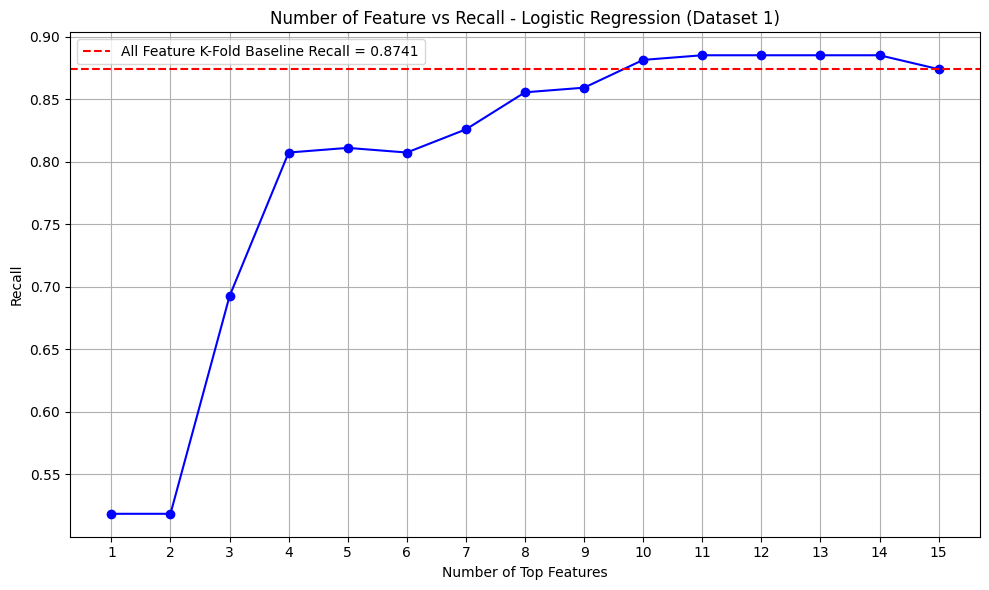

In [3]:
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

#Dataset 1
print("DATASET 1: Lung Cancer Dataset")

pd.set_option('display.max_columns', None)

#df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')

df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])

df_Lung_Cancer.columns = df_Lung_Cancer.columns.str.strip()

print("First 5 rows")
print(df_Lung_Cancer.head())

print("\nColumn names:")
print(df_Lung_Cancer.columns.tolist())

print("\nDataset info:")
df_Lung_Cancer.info()

print("\nMissing values:")
print(df_Lung_Cancer.isnull().sum())

for col in df_Lung_Cancer.columns:
    if df_Lung_Cancer[col].dtype == "object":
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].mode()[0])
    else:
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].median())

print("\nMissing values after filling:")
print(df_Lung_Cancer.isnull().sum())

X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)



# Logistic Regression model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X1_scaled, y1, test_size=0.2, random_state=42) #https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/

model.fit(X_train, y_train)

print(classification_report(y_test,model.predict(X_test)))


# Predictions
y_pred1 = model.predict(X_test)

#Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")
print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")
print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")
print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_)
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy" : "accuracy",
    "precision" : "precision",
    "recall" : "recall",
    "f1" : "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1_scaled,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results : Dataset 1 (5-fold CV Baseline - All features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-in-logistic-regression-models/
lr_model_full = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr_model_full.fit(X1_scaled, y1)

feature_importance_df = pd.DataFrame({
    "Feature" : X1.columns,
    "Importance": np.abs(lr_model_full.coef_[0])
}) .sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking (Absolute Coefficient Magnitude)")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Logistic Regressions (Dataset 1)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#INDIVIDUAL FEATURE EXPERIMENTS

individual_feature_results = []

for feature in feature_importance_df["Feature"]:
  X_single = X1[[feature]]

  scaler_single = StandardScaler()
  X_single_scaled = scaler_single.fit_transform(X_single)

  single_model = LogisticRegression(
      random_state=42,
      class_weight="balanced",
      max_iter=1000
  )

  single_cv_results = cross_validate(
      single_model,
      X_single_scaled,
      y1,
      cv=cv,
      scoring=scoring,
      n_jobs=-1
    )

  individual_feature_results.append({
      "Feature_Set": feature,
      "Num_Feature": 1,
      "Accuracy": single_cv_results["test_accuracy"].mean(),
      "Precision": single_cv_results["test_precision"].mean(),
      "Recall": single_cv_results["test_recall"].mean(),
      "F1-score": single_cv_results["test_f1"].mean()
  })

  individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
      by="Recall",
      ascending=False
  ).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS

ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range (1, len(ranked_features) + 1):
      selected_features = ranked_features[:k]
      X_topk = X1[selected_features]

      #Scale the top-k features

      scaler_topk = StandardScaler()
      X_topk_scaled = scaler_topk.fit_transform(X_topk)

      topk_model = LogisticRegression(
          random_state=42,
          class_weight="balanced",
          max_iter=1000
      )

      topk_cv_results = cross_validate(
          topk_model,
          X_topk_scaled,
          y1,
          cv=cv,
          scoring=scoring,
          n_jobs=-1
      )

      topk_results.append({
          "Num_Features": k,
          "Features_Used": ", ".join(selected_features),
          "Accuracy": topk_cv_results["test_accuracy"].mean(),
          "Precision": topk_cv_results["test_precision"].mean(),
          "Recall": topk_cv_results["test_recall"].mean(),
          "F1-score": topk_cv_results["test_f1"].mean()
      })

      topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
          "Num_Features" : X1.shape [1],
          "Features_Used": "All Features (Official Baseline)",
          "Accuracy": baseline_accuracy_cv,
          "Precision": baseline_precision_cv,
          "Recall": baseline_recall_cv,
          "F1-score": baseline_f1_cv

      }])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL

plt.figure(figsize=(10,6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o", color="blue")
plt.axhline(
          y=baseline_recall_cv,
          color="red",
          linestyle="--",
          label=f"All Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Feature vs Recall - Logistic Regression (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




DATASET 2: Lung Cancer Prediction Dataset
First 5 rows
   AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURATION  \
0         

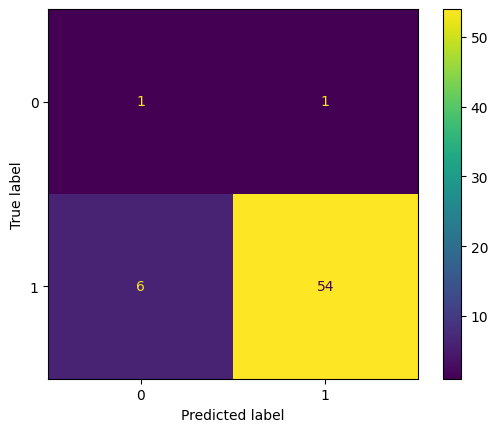


Logistic Regression Results: Dataset 2 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8784
Mean Precision: 0.8112
Mean Recall   : 0.9146
Mean F1-score : 0.8597

Feature Importance Ranking (Absolute Coefficient Magnitude)
                   Feature  Importance
0                  SMOKING    1.525749
1        THROAT_DISCOMFORT    1.175328
2          BREATHING_ISSUE    1.140644
3   SMOKING_FAMILY_HISTORY    0.774546
4            STRESS_IMMUNE    0.747416
5             ENERGY_LEVEL    0.675255
6    EXPOSURE_TO_POLLUTION    0.400234
7           FAMILY_HISTORY    0.228417
8     FINGER_DISCOLORATION    0.056415
9        OXYGEN_SATURATION    0.048125
10         CHEST_TIGHTNESS    0.043707
11           MENTAL_STRESS    0.028376
12     ALCOHOL_CONSUMPTION    0.026084
13                  GENDER    0.022382
14         IMMUNE_WEAKNESS    0.015085
15                     AGE    0.008182
16       LONG_TERM_ILLNESS    0.004759


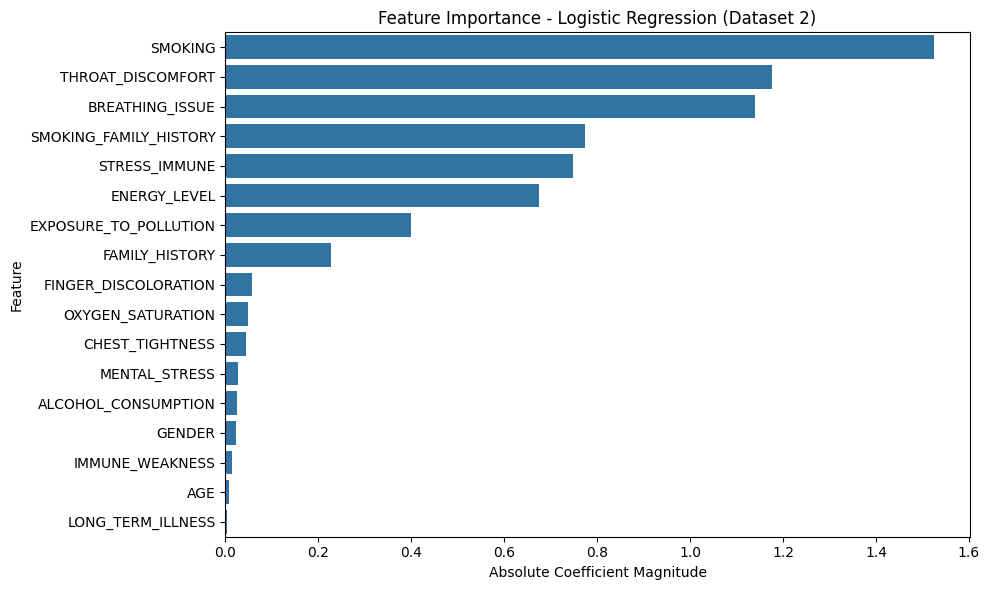


Individual Feature Results (5-Fold CV)
               Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0          BREATHING_ISSUE             1    0.5506   0.473846  0.930779   
1                  SMOKING             1    0.6830   0.567832  0.928816   
2        THROAT_DISCOMFORT             1    0.5912   0.499271  0.855173   
3     FINGER_DISCOLORATION             1    0.4938   0.417845  0.616573   
4          CHEST_TIGHTNESS             1    0.4940   0.417942  0.616111   
5            MENTAL_STRESS             1    0.5364   0.447877  0.593549   
6             ENERGY_LEVEL             1    0.5750   0.481753  0.573871   
7    EXPOSURE_TO_POLLUTION             1    0.5438   0.452914  0.573396   
8                      AGE             1    0.5040   0.412173  0.510560   
9      ALCOHOL_CONSUMPTION             1    0.4832   0.391886  0.499768   
10       OXYGEN_SATURATION             1    0.4996   0.405841  0.492899   
11                  GENDER             1    0.4910   0.39732

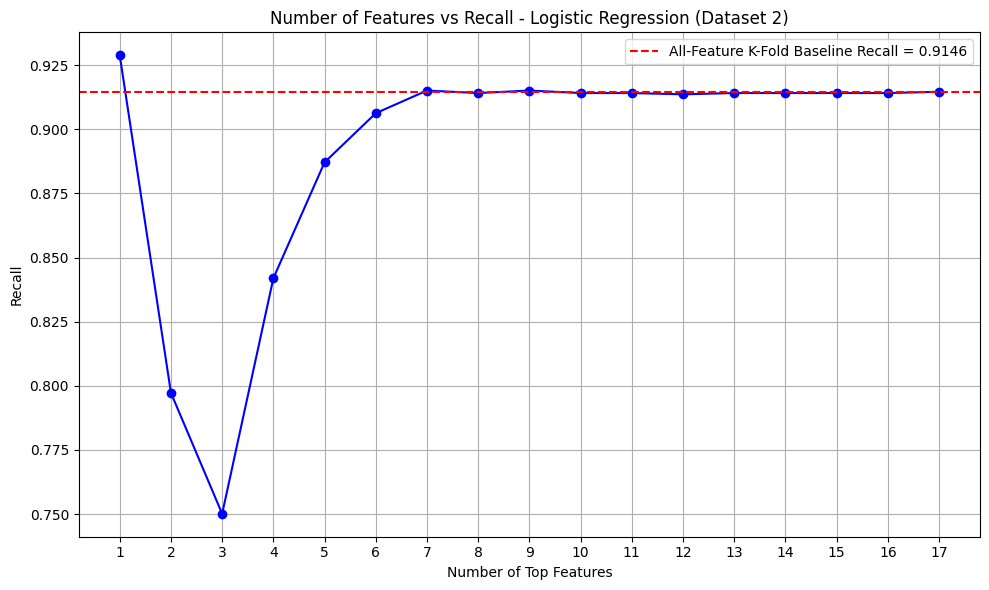

In [16]:
print("DATASET 2: Lung Cancer Prediction Dataset")

pd.set_option('display.max_columns', None)

df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'])

for col in df_Lung_Cancer_Prediction_Dataset.columns:
  if df_Lung_Cancer_Prediction_Dataset[col].dtype == 'object':
      df_Lung_Cancer_Prediction_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset[col])

df_Lung_Cancer_Prediction_Dataset.columns = df_Lung_Cancer_Prediction_Dataset.columns.str.strip()

print("First 5 rows")
print(df_Lung_Cancer_Prediction_Dataset.head())

print("\nColumn names:")
print(df_Lung_Cancer_Prediction_Dataset.columns.tolist())

print("\nDataset info:")
df_Lung_Cancer_Prediction_Dataset.info()

print("\nMissing values:")
print(df_Lung_Cancer_Prediction_Dataset.isnull().sum())

for col in df_Lung_Cancer_Prediction_Dataset.columns:
    if df_Lung_Cancer_Prediction_Dataset[col].dtype == "object":
        df_Lung_Cancer_Prediction_Dataset[col] = df_Lung_Cancer_Prediction_Dataset[col].fillna(df_Lung_Cancer_Prediction_Dataset[col].mode()[0])
    else:
        df_Lung_Cancer_Prediction_Dataset[col] = df_Lung_Cancer_Prediction_Dataset[col].fillna(df_Lung_Cancer_Prediction_Dataset[col].median())

print("\nMissing values after filling:")
print(df_Lung_Cancer_Prediction_Dataset.isnull().sum())


# Prepare features and target
X2 = df_Lung_Cancer_Prediction_Dataset.drop(columns=['PULMONARY_DISEASE'])
y2 = df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE']

# Scale features
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Logistic Regression model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")
print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")
print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")
print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_)
disp.plot()
plt.show()

# BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X2_scaled,
    y2,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results: Dataset 2 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE (using coefficients from Logistic Regression)
lr_model_full = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr_model_full.fit(X2_scaled, y2)

# Get absolute coefficients for feature importance
feature_importance_df = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": np.abs(lr_model_full.coef_[0])
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking (Absolute Coefficient Magnitude)")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Logistic Regression (Dataset 2)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
  X_single = X2[[feature]]
  # Scale the single feature
  scaler_single = StandardScaler()
  X_single_scaled = scaler_single.fit_transform(X_single)

  single_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
  )

  single_cv_results = cross_validate(
       single_model,
       X_single_scaled,
       y2,
       cv=cv,
       scoring=scoring,
       n_jobs=-1
  )

  individual_feature_results.append({
      "Feature_Set": feature,
      "Num_Features": 1,
      "Accuracy": single_cv_results["test_accuracy"].mean(),
      "Precision": single_cv_results["test_precision"].mean(),
      "Recall": single_cv_results["test_recall"].mean(),
      "F1-score": single_cv_results["test_f1"].mean()
  })


individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range (1, len(ranked_features) +1):
    selected_features = ranked_features[:k]
    X_topk =X2[selected_features]

    # Scale the top-k features
    scaler_topk = StandardScaler()
    X_topk_scaled = scaler_topk.fit_transform(X_topk)

    topk_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk_scaled,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X2.shape[1],
    "Features_Used": "All Features (Offical Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)


# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o", color="blue")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Logistic Regression (Dataset 2)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



DATASET 3: Lung Cancer Risk Dataset
First 5 rows
   patient_id  age  gender  pack_years  radon_exposure  asbestos_exposure  \
0      100000   69       1   66.025244               0                  0   
1      100001   32       0   12.780800               0                  0   
2      100002   89       0    0.408278               2                  1   
3      100003   78       0   44.065232               1                  0   
4      100004   38       0   44.432440               2                  1   

   secondhand_smoke_exposure  copd_diagnosis  alcohol_consumption  \
0                          0               1                    1   
1                          1               1                    1   
2                          1               1                    2   
3                          1               0                    1   
4                          0               1                    2   

   family_history  lung_cancer  
0               0            0  
1      

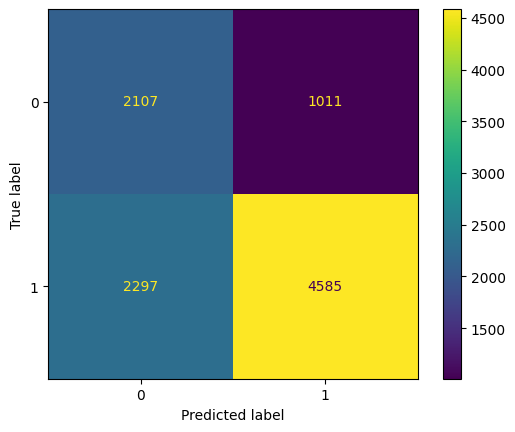


Logistic Regression Results: Dataset 3 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.6652
Mean Precision: 0.8149
Mean Recall   : 0.6637
Mean F1-score : 0.7315

Feature Importance Ranking (Absolute Coefficient Magnitude)
                     Feature  Importance
0                 pack_years    0.508937
1          asbestos_exposure    0.409120
2             copd_diagnosis    0.400392
3                        age    0.314790
4             radon_exposure    0.313512
5             family_history    0.278358
6  secondhand_smoke_exposure    0.253461
7        alcohol_consumption    0.084229
8                     gender    0.000318


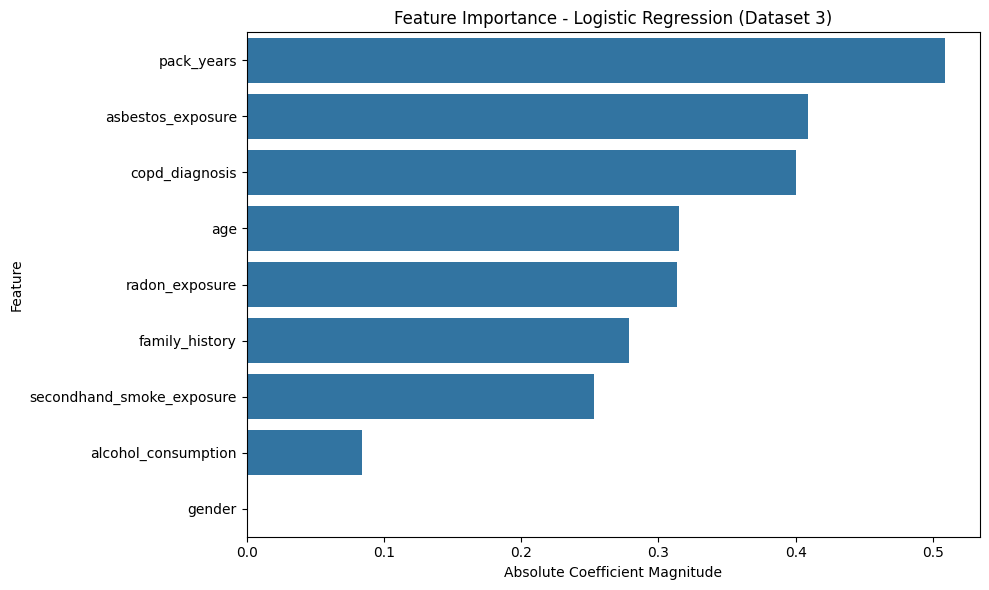


Individual Feature Results (5-Fold CV)
                 Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0             radon_exposure             1   0.59422   0.711196  0.689617   
1        alcohol_consumption             1   0.57288   0.695101  0.674339   
2                 pack_years             1   0.58410   0.757839  0.580288   
3                        age             1   0.56402   0.743599  0.558084   
4             copd_diagnosis             1   0.57168   0.758276  0.553108   
5          asbestos_exposure             1   0.57182   0.760670  0.550052   
6             family_history             1   0.54942   0.736869  0.535706   
7  secondhand_smoke_exposure             1   0.54542   0.732083  0.534018   
8                     gender             1   0.49478   0.682097  0.496188   

   F1-score  
0  0.700229  
1  0.684555  
2  0.657264  
3  0.637616  
4  0.639627  
5  0.638434  
6  0.620373  
7  0.617544  
8  0.574462  

Top-k Feature Combination Results (5-Fold CV)
  

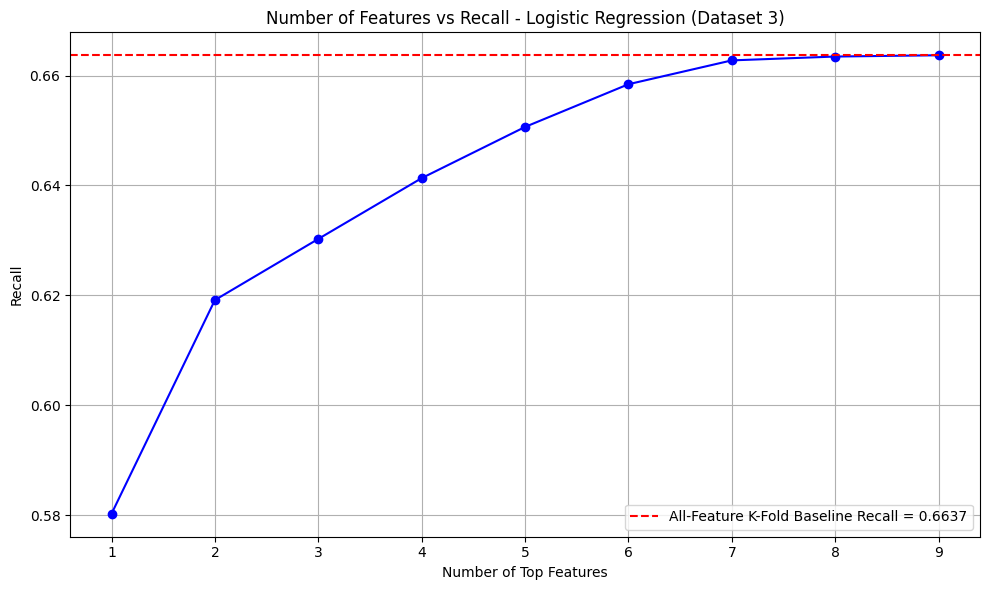

In [12]:
print ("DATASET 3: Lung Cancer Risk Dataset")

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')

pd.set_option('display.max_columns', None)

# Encode all columns
for col in df_Lung_Cancer_Risk_Dataset.columns:
    if not pd.api.types.is_numeric_dtype(df_Lung_Cancer_Risk_Dataset[col]):
        df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col].astype(str))

# Clean column names
df_Lung_Cancer_Risk_Dataset.columns = df_Lung_Cancer_Risk_Dataset.columns.str.strip()

print("First 5 rows")
print(df_Lung_Cancer_Risk_Dataset.head())

print("\nColumn names:")
print(df_Lung_Cancer_Risk_Dataset.columns.tolist())

print("\nDataset info:")
df_Lung_Cancer_Risk_Dataset.info()

print("\nMissing values:")
print(df_Lung_Cancer_Risk_Dataset.isnull().sum())

# DROP ID COLUMN IF IT EXISTS
if "patient_id" in df_Lung_Cancer_Risk_Dataset.columns:
    df_Lung_Cancer_Risk_Dataset = df_Lung_Cancer_Risk_Dataset.drop(columns=["patient_id"])

for col in df_Lung_Cancer_Risk_Dataset.columns:
    if df_Lung_Cancer_Risk_Dataset[col].dtype == "object":
        df_Lung_Cancer_Risk_Dataset[col] = df_Lung_Cancer_Risk_Dataset[col].fillna(df_Lung_Cancer_Risk_Dataset[col].median())
    else:
        df_Lung_Cancer_Risk_Dataset[col] = df_Lung_Cancer_Risk_Dataset[col].fillna(df_Lung_Cancer_Risk_Dataset[col].median())

print("\nMissing values after filling:")
print(df_Lung_Cancer_Risk_Dataset.isnull().sum())

X3 = df_Lung_Cancer_Risk_Dataset.drop(columns=['lung_cancer'])
y3 = df_Lung_Cancer_Risk_Dataset['lung_cancer']

# Scale features
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

# BASELINE MODEL
model= LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3_scaled, y3, test_size=0.2, random_state=42)

model.fit(X_train3, y_train3)

print(classification_report(y_test3, model.predict(X_test3)))

print(f"\nAccuracy: {accuracy_score(y_test3, model.predict(X_test3)):.4f}")
print(f"F1-Score: {f1_score(y_test3, model.predict(X_test3)):.4f}")
print(f"Precision: {precision_score(y_test3, model.predict(X_test3)):.4f}")
print(f"Recall: {recall_score(y_test3, model.predict(X_test3)):.4f}")

print(confusion_matrix(y_test3, model.predict(X_test3)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test3, model.predict(X_test3)),
                              display_labels=model.classes_)
disp.plot()
plt.show()

# BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X3_scaled,
    y3,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results: Dataset 3 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")




